# Appendix 4. UMAP + HDBSCAN (3D / 4D)

The notebook 2 run embedded into 3 and 4 dimensions instead of 2 dimension.

| input | what it provides |
| --- | --- |
| `metadata/params.csv` | one row per spectrum: the table built in notebook 0; fixes the row order |
| `data/F30_norm.csv` | one column per spectrum: the continuum removed fluxes built in notebook 1 |

| output | |
| --- | --- |
| `results/umap_5100_6450_dim3_nei12_eps0475_lab2d.csv` | `params.csv` with `umap_x`, `umap_y`, `umap_z` and `DB_label` appended |
| `results/umap_5100_6450_dim4_nei12_eps0475_lab2d.csv` | the same, with `umap_w` as well |


## Imports

In [1]:
import os

import pandas as pd

In [2]:
import hdbscan
import umap

In [3]:
import matplotlib.pyplot as plt

## Configuration


In [ ]:
# Input / output locations
PARAMS_PATH = './metadata/params.csv'
SPECTRUM_TABLE_PATH = './data/F30_norm.csv'

RESULTS_DIR = './results'

# Wavelength window handed to UMAP [Angstrom].  It covers the Si II 5972 and
# 6355 features, the part of the spectrum the classification rests on, and is
# narrower than the 5000-7000 grid the spectrum table is sampled on.
WINDOW_MIN_AA = 5100
WINDOW_MAX_AA = 6450

# Column label format written by notebook 1: '<SN name>%%%<SN type>$$$<phase>'
NAME_TYPE_SEPARATOR = '%%%'

In [5]:
# UMAP.  `min_dist = 0` packs each group as tightly as UMAP allows, which is what
# HDBSCAN wants to see; `random_state` fixes the layout across runs.  Only the
# number of components varies between the runs below.
UMAP_N_NEIGHBORS = 12
UMAP_MIN_DIST = 0.0
UMAP_METRIC = 'euclidean'
UMAP_RANDOM_STATE = 50

# The embedding HDBSCAN is run on.  Its labels are the DB_label of every table
# written below, so the clustering stays the two dimensional one.
LABEL_N_COMPONENTS = 2

# The embeddings written out, one file each.
OUTPUT_N_COMPONENTS = [3, 4]

# HDBSCAN.  `leaf` selection keeps the small subtypes apart instead of merging
# them into their parent cluster; the epsilon then sets how close two leaves have
# to be before they are joined again.
HDBSCAN_MIN_CLUSTER_SIZE = 2
HDBSCAN_CLUSTER_SELECTION_EPSILON = 0.475
HDBSCAN_CLUSTER_SELECTION_METHOD = 'leaf'

# Columns appended to params.csv.  The first `n_components` names are used, so a
# 3D run writes umap_x, umap_y, umap_z and a 4D run adds umap_w.
EMBEDDING_COLUMN_NAMES = ['umap_x', 'umap_y', 'umap_z', 'umap_w']
LABEL_COLUMN = 'DB_label'

# HDBSCAN marks a point it leaves out of every cluster with this label
NOISE_LABEL = -1

In [6]:
# The settings above name the output.  The epsilon drops its decimal point
# (0.475 -> 0475), the convention the earlier result files were named by; the
# `lab2d` tag records that the labels come from the two dimensional embedding
# rather than from the one stored in the file.
EPSILON_TAG = str(HDBSCAN_CLUSTER_SELECTION_EPSILON).replace('.', '')


def embedding_columns(n_components):
    """Column names of an embedding of `n_components` dimensions."""
    if n_components > len(EMBEDDING_COLUMN_NAMES):
        raise ValueError(f'no column name for dimension {len(EMBEDDING_COLUMN_NAMES) + 1} '
                         f'and beyond; extend EMBEDDING_COLUMN_NAMES')

    return EMBEDDING_COLUMN_NAMES[:n_components]


def results_path(n_components):
    """Where the table of an `n_components` dimensional embedding is written."""
    return (f'{RESULTS_DIR}/umap_{WINDOW_MIN_AA}_{WINDOW_MAX_AA}'
            f'_dim{n_components}_nei{UMAP_N_NEIGHBORS}_eps{EPSILON_TAG}'
            f'_lab{LABEL_N_COMPONENTS}d.csv')


[results_path(n) for n in OUTPUT_N_COMPONENTS]

['./results/umap_5100_6450_dim3_nei12_eps0475_lab2d.csv',
 './results/umap_5100_6450_dim4_nei12_eps0475_lab2d.csv']

## Reading the inputs


In [7]:
def load_params(params_path=PARAMS_PATH):
    """Read the metadata table built in notebook 0.

    Its row order becomes the row order of the results table.
    """
    return pd.read_csv(params_path)

In [8]:
def load_fluxes(params, spectrum_path=SPECTRUM_TABLE_PATH,
                window_min=WINDOW_MIN_AA, window_max=WINDOW_MAX_AA):
    """Read the normalized spectrum table of notebook 1 as one row per supernova.

    The table holds one column per spectrum, labelled
    `<SN name>%%%<SN type>$$$<phase>`, and one row per wavelength bin.  It is cut
    to the window given, transposed so that each supernova becomes a row and each
    wavelength a feature, and reordered to follow the rows of `params` so that the
    embedding can be written straight back next to the metadata.
    """
    spectra = pd.read_csv(spectrum_path).set_index('AA')
    spectra = spectra[(spectra.index > window_min) & (spectra.index < window_max)]

    column_of = {column.split(NAME_TYPE_SEPARATOR)[0]: column for column in spectra.columns}
    if len(column_of) != len(spectra.columns):
        raise ValueError('the spectrum table holds more than one spectrum per supernova')

    # A missing supernova raises a KeyError naming it
    ordered = spectra[[column_of[name] for name in params['SN_name']]]

    return ordered.T.reset_index(drop=True)

## Embedding and clustering

UMAP reduces the fluxes to the number of dimensions asked for.  HDBSCAN sees only
the two dimensional embedding, never the fluxes and never the 3D or 4D runs.


In [9]:
def embed(fluxes, n_components, n_neighbors=UMAP_N_NEIGHBORS,
          min_dist=UMAP_MIN_DIST, metric=UMAP_METRIC, random_state=UMAP_RANDOM_STATE):
    """UMAP embedding of the fluxes in `n_components` dimensions, one row per supernova."""
    reducer = umap.UMAP(n_components=n_components, n_neighbors=n_neighbors,
                        min_dist=min_dist, metric=metric, random_state=random_state)

    return reducer.fit_transform(fluxes)

In [10]:
def cluster(embedding, min_cluster_size=HDBSCAN_MIN_CLUSTER_SIZE,
            cluster_selection_epsilon=HDBSCAN_CLUSTER_SELECTION_EPSILON,
            cluster_selection_method=HDBSCAN_CLUSTER_SELECTION_METHOD):
    """HDBSCAN label of every embedded spectrum; -1 is a spectrum left unclustered."""
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        cluster_selection_epsilon=cluster_selection_epsilon,
        cluster_selection_method=cluster_selection_method,
    ).fit(embedding)

    return clusterer.labels_

## Run


In [11]:
params = load_params()
fluxes = load_fluxes(params)
print(f'{len(fluxes)} spectra x {fluxes.shape[1]} wavelength bins '
      f'({WINDOW_MIN_AA}-{WINDOW_MAX_AA} A)')

119 spectra x 675 wavelength bins (5100-6450 A)


### The labels

The two dimensional embedding and its HDBSCAN labels.  Only `labels` is used
further down; `label_embedding` is kept for the check below.


In [12]:
label_embedding = embed(fluxes, n_components=LABEL_N_COMPONENTS)
labels = cluster(label_embedding)

n_clusters = len(set(labels) - {NOISE_LABEL})
n_noise = int((labels == NOISE_LABEL).sum())
print(f'{n_clusters} clusters, {n_noise} spectra unclustered '
      f'(from the {LABEL_N_COMPONENTS}D embedding)')

6 clusters, 4 spectra unclustered (from the 2D embedding)


### The 3D and 4D embeddings


In [13]:
embeddings = {n: embed(fluxes, n_components=n) for n in OUTPUT_N_COMPONENTS}

tables = {}
for n_components, embedding in embeddings.items():
    table = params.copy()
    table[embedding_columns(n_components)] = embedding
    table[LABEL_COLUMN] = labels
    tables[n_components] = table

    print(f'{n_components}D: {", ".join(embedding_columns(n_components))}')

tables[OUTPUT_N_COMPONENTS[-1]].head()

3D: umap_x, umap_y, umap_z
4D: umap_x, umap_y, umap_z, umap_w


,SN_name,RA,DEC,redshift,host_name,Host_RA,Host_DEC,logd25,e_logd25,logr25,...,D15,D15_err,phase,filename_csv,Del_Lambda,umap_x,umap_y,umap_z,umap_w,DB_label
0,SN1994D,188.51021,7.70131,0.001494,NGC4526,188.512545,7.699261,1.842,0.018,0.449,...,1.37,0.03,0.35,SN1994D_1994-03-21_08-24-00_FLWO-1.5m_FAST_CfA...,1.467083,5.186393,7.846188,3.426998,0.749085,5
1,SN1994S,187.84108,29.13450,0.015177,NGC4495,187.845363,29.136442,1.128,0.035,0.373,...,0.94,0.06,1.00,SN_1994S_1994-06-16_00-00-00_Lick-3m_KAST_UCB-...,1.969612,5.578704,7.409799,4.064739,0.696751,5
2,SN1996ai,197.74221,37.05983,0.002900,NGC5005,197.734470,37.058994,1.683,0.025,0.500,...,0.88,0.06,-0.10,SN_1996ai_1996-06-21_00-00-00_Lick-3m_KAST_UCB...,1.992704,5.279991,7.734963,5.152100,2.001994,3
3,SN1996C,207.70250,49.31864,0.027000,PGC049153,207.703404,49.315106,0.899,0.064,0.257,...,0.93,0.06,1.98,1996C_1996-02-17_11-31-12_FLWO-1.5m_FAST_CfA-I...,1.430809,5.723428,7.815962,4.017652,1.575025,3
4,SN1996X,199.50471,-26.84592,0.008876,NGC5061,199.521255,-26.837131,1.574,0.027,0.092,...,1.26,0.04,0.31,SN1996X_1996-04-18_07-26-24_FLWO-1.5m_FAST_CfA...,1.456511,4.509780,8.245711,3.144539,2.383020,2


### Check


In [14]:
def plot_embedding(embedding, labels, columns, title=None):
    """Scatter of an embedding coloured by cluster label.

    Two dimensions are drawn as one plane, three as one 3D axes, and more as
    consecutive pairs of coordinates side by side.
    """
    n_components = embedding.shape[1]
    projections = ([tuple(range(n_components))] if n_components <= 3
                   else [(i, i + 1) for i in range(0, n_components - 1, 2)])
    is_3d = n_components == 3

    fig, axes = plt.subplots(
        1, len(projections), figsize=(5.5 * len(projections), 5.5), dpi=120,
        squeeze=False, subplot_kw={'projection': '3d'} if is_3d else {})

    for ax, axis_indices in zip(axes[0], projections):
        for label in sorted(set(labels)):
            in_cluster = labels == label
            name = 'unclustered' if label == NOISE_LABEL else f'cluster {label}'
            ax.scatter(*[embedding[in_cluster, i] for i in axis_indices], s=20,
                       label=name, color='lightgrey' if label == NOISE_LABEL else None)

        ax.set_xlabel(columns[axis_indices[0]])
        ax.set_ylabel(columns[axis_indices[1]])
        if is_3d:
            ax.set_zlabel(columns[axis_indices[2]])

    axes[0][0].legend(loc='best', fontsize=7)
    if title is not None:
        fig.suptitle(title)

    plt.show()

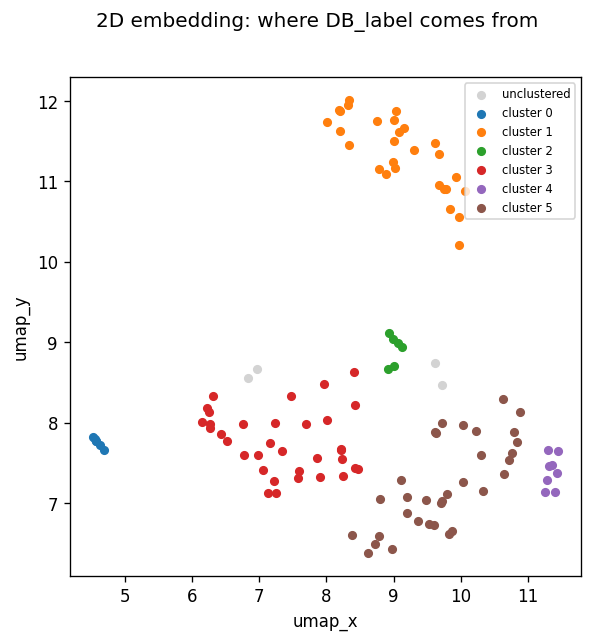

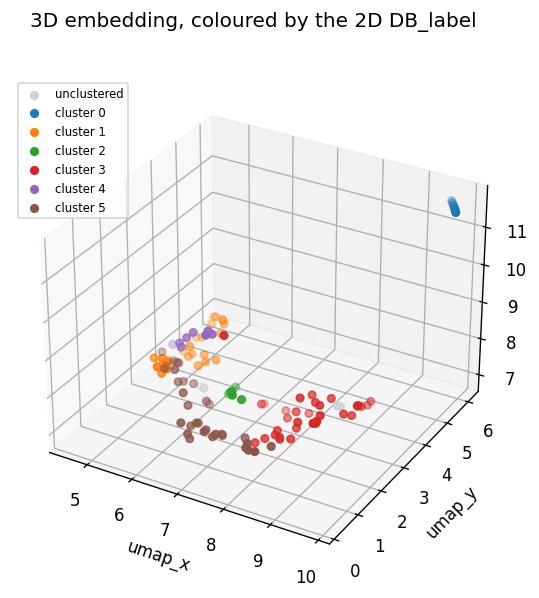

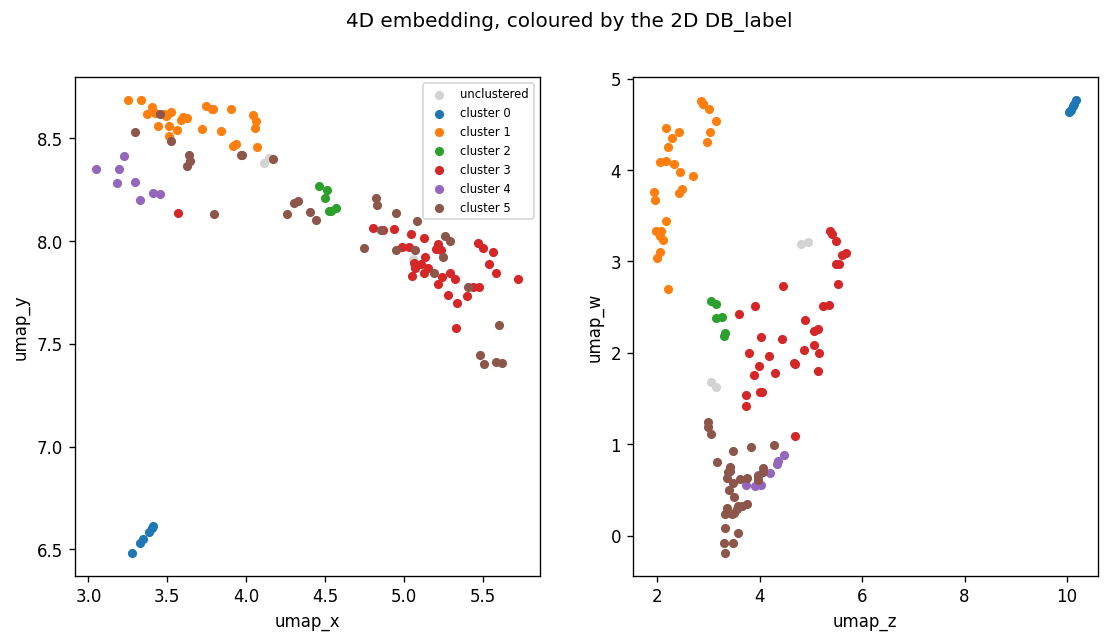

In [15]:
plot_embedding(label_embedding, labels, embedding_columns(LABEL_N_COMPONENTS),
               title=f'{LABEL_N_COMPONENTS}D embedding: where DB_label comes from')

for n_components, embedding in embeddings.items():
    plot_embedding(embedding, labels, embedding_columns(n_components),
                   title=f'{n_components}D embedding, coloured by the '
                         f'{LABEL_N_COMPONENTS}D DB_label')

## Write the tables


In [16]:
os.makedirs(RESULTS_DIR, exist_ok=True)

for n_components, table in tables.items():
    path = results_path(n_components)
    table.to_csv(path, index=False)
    print(f'written to {path}')

written to ./results/umap_5100_6450_dim3_nei12_eps0475_lab2d.csv
written to ./results/umap_5100_6450_dim4_nei12_eps0475_lab2d.csv
